dict_keys(['mistral-7b', 'yi-34b', 'vicuna-13b'])


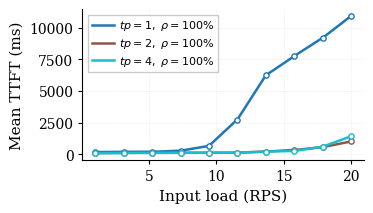

In [51]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Same logic as notebooks/plot_latencies.py — set METRIC to match your pickle
# (build_ttft_lookup_tables --metric ttft | p95_ttft, or --metrics ttft p95_ttft).
METRIC = "ttft"
METRIC_YLABEL = {
    "ttft": "Mean TTFT (ms)",
    "p95_ttft": "P95 TTFT (ms)",
}
# Log scale on y: set True. All y values must be > 0 (Matplotlib requirement).
USE_LOG_Y = False

# Keep only measured loads strictly below this (RPS). None = use all loads.
MAX_LOAD_RPS = None # e.g. 25.0


def get_model_table(data, model_id, metric):
    """Flat: one metric per file. Nested: data[model_id][metric][(tp, th)][load]."""
    m = data[model_id]
    k0 = next(iter(m.keys()))
    if isinstance(k0, tuple):
        return m
    return m[metric]

# ---------------------------
# Load lookup tables
# ---------------------------
with open("outputs/ttft_p95_lookup.pkl", "rb") as f:
    data = pickle.load(f)
print(data.keys())
# Each entry: (model_id, tp_level, thread_percentage_level) → one colored series on the same axes.
# Example: sweep threads — panels = [("mistral-7b", 4, th) for th in range(10, 101, 10)]
panels = [
    ("yi-34b", 1, 100),
    ("yi-34b", 2, 100),
    ("yi-34b", 4, 100),
]

# ---------------------------
# Paper-ready style
# ---------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3.0,
    "ytick.major.size": 3.0,
    "lines.linewidth": 1.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Single axes: all series overlaid with one legend
n_series = len(panels)
fig, ax = plt.subplots(figsize=(3.6, 2))
colors = plt.cm.tab10(np.linspace(0, 1, max(n_series, 3)))

for i, (model_id, tp_level, thread_percentage_level) in enumerate(panels):
    key = (tp_level, thread_percentage_level)
    model_data = get_model_table(data, model_id, METRIC)
    if key not in model_data:
        raise KeyError(
            f"Missing lookup for {model_id} at {key}. "
            f"Available keys: {sorted(model_data.keys())}"
        )

    load_to_ttft_ms = model_data[key]
    loads = np.asarray(sorted(load_to_ttft_ms.keys()), dtype=float)
    ttft_ms = np.asarray([load_to_ttft_ms[float(l)] for l in loads], dtype=float)

    if MAX_LOAD_RPS is not None:
        mask = loads < float(MAX_LOAD_RPS)
        loads = loads[mask]
        ttft_ms = ttft_ms[mask]
    if loads.size == 0:
        hint = (
            f" (no loads < {MAX_LOAD_RPS} RPS; raise MAX_LOAD_RPS or set None)"
            if MAX_LOAD_RPS is not None
            else ""
        )
        raise ValueError(f"No load points for {model_id} {key}{hint}.")

    if loads.size >= 2:
        x_dense = np.linspace(loads.min(), loads.max(), 400)
        y_interp = np.interp(x_dense, loads, ttft_ms)
    else:
        x_dense = loads
        y_interp = ttft_ms

    c = colors[i % len(colors)]
    label=rf"$tp={tp_level},\ \rho={thread_percentage_level}\%$"

    ax.plot(
        x_dense,
        y_interp,
        color=c,
        linestyle="-",
        linewidth=1.8,
        label=label,
    )
    ax.plot(
        loads,
        ttft_ms,
        linestyle="none",
        marker="o",
        markersize=3.8,
        markerfacecolor="white",
        markeredgecolor=c,
        markeredgewidth=1.0,
        zorder=3,
    )

ax.set_xlabel("Input load (RPS)")
ax.set_ylabel(METRIC_YLABEL.get(METRIC, METRIC))
ax.grid(True, axis="both", linestyle=":", linewidth=0.6, alpha=0.3)
ax.set_axisbelow(True)

ax.legend(
    loc="best",
    frameon=True,
    fancybox=False,
    edgecolor="0.8",
    facecolor="white",
    framealpha=1.0,
    fontsize=8,
    borderpad=0.35,
    handlelength=2.0,
    handletextpad=0.45,
    labelspacing=0.35,
)

plt.tight_layout(pad=0.2)

# ---------------------------
# Save
# ---------------------------
out_dir = Path("plots")
out_dir.mkdir(parents=True, exist_ok=True)
slug = "_".join(f"{m}_tp{t}_th{th}" for m, t, th in panels)
out_path = out_dir / f"ttft_overlay_{METRIC}_{slug}.pdf"
# plt.savefig(out_path, bbox_inches="tight", pad_inches=0.02)
# print(f"Saved: {out_path}")

plt.show()